# Variational Autoencoders (VAE) sur 10% de MNIST

Ce notebook reprend la logique du notebook 082 en l'adaptant à un VAE entièrement connecté sur un sous-échantillon stratifié de 10% de MNIST.
On garde le même déroulé: préparation des données, recherche d'hyperparamètres, entraînement final, évaluation et visualisations des reconstructions et de l'espace latent.

In [1]:
import sys
import subprocess
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

try:
    import optuna
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "--quiet"])
    import optuna

np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [2]:
print("Chargement de MNIST...")
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist.data.astype(np.float32) / 255.0
y = mnist.target.astype(int)

X_sample, _, y_sample, _ = train_test_split(
    X,
    y,
    train_size=0.10,
    stratify=y,
    random_state=42,
)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_sample,
    y_sample,
    test_size=0.30,
    stratify=y_sample,
    random_state=42,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42,
)

print(f"X total        : {X.shape}")
print(f"X 10% sample   : {X_sample.shape}")
print(f"Train / Val / Test : {X_train.shape} / {X_val.shape} / {X_test.shape}")
print("Distribution train:", np.bincount(y_train))
print("Distribution val  :", np.bincount(y_val))
print("Distribution test :", np.bincount(y_test))

Chargement de MNIST...
X total        : (70000, 784)
X 10% sample   : (7000, 784)
Train / Val / Test : (4900, 784) / (1050, 784) / (1050, 784)
Distribution train: [483 552 489 500 477 442 482 510 478 487]
Distribution val  : [104 118 105 107 103  94 103 109 102 105]
Distribution test : [103 118 105 107 102  95 103 110 103 104]


In [3]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_multiplier, activation="relu"):
        super().__init__()
        hidden_dim = latent_dim * hidden_multiplier
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            self._make_activation(activation),
            nn.Linear(hidden_dim, hidden_dim),
            self._make_activation(activation),
        )
        self.mu_layer = nn.Linear(hidden_dim, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            self._make_activation(activation),
            nn.Linear(hidden_dim, hidden_dim),
            self._make_activation(activation),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

    def _make_activation(self, activation):
        if activation == "tanh":
            return nn.Tanh()
        return nn.ReLU()

    def encode(self, x):
        hidden = self.encoder(x)
        mu = self.mu_layer(hidden)
        logvar = self.logvar_layer(hidden)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar, z


def make_dataloader(X_array, batch_size, shuffle):
    tensor = torch.tensor(X_array, dtype=torch.float32)
    dataset = TensorDataset(tensor, tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=False)


def vae_loss_function(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction="sum")
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss


def train_vae(model, train_loader, val_loader, learning_rate, alpha, beta, max_epochs, patience=6):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=alpha)
    best_state = None
    best_val = float("inf")
    wait = 0
    history = []

    for epoch in range(max_epochs):
        model.train()
        train_total = 0.0
        train_recon = 0.0
        train_kl = 0.0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            recon, mu, logvar, _ = model(xb)
            loss, recon_loss, kl_loss = vae_loss_function(recon, yb, mu, logvar, beta=beta)
            loss.backward()
            optimizer.step()
            train_total += loss.item()
            train_recon += recon_loss.item()
            train_kl += kl_loss.item()

        model.eval()
        val_total = 0.0
        val_recon = 0.0
        val_kl = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                recon, mu, logvar, _ = model(xb)
                loss, recon_loss, kl_loss = vae_loss_function(recon, yb, mu, logvar, beta=beta)
                val_total += loss.item()
                val_recon += recon_loss.item()
                val_kl += kl_loss.item()

        train_size = len(train_loader.dataset)
        val_size = len(val_loader.dataset)
        input_dim = train_loader.dataset.tensors[0].shape[1]
        history.append({
            "epoch": epoch + 1,
            "train_total": train_total / train_size,
            "train_recon": train_recon / train_size,
            "train_kl": train_kl / train_size,
            "val_total": val_total / val_size,
            "val_recon": val_recon / val_size,
            "val_kl": val_kl / val_size,
            "train_mse_proxy": train_recon / (train_size * input_dim),
            "val_mse_proxy": val_recon / (val_size * input_dim),
        })

        current_val = val_total / val_size
        if current_val < best_val - 1e-6:
            best_val = current_val
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history), best_val


def evaluate_vae(model, X_array, beta=1.0, batch_size=256):
    loader = make_dataloader(X_array, batch_size=batch_size, shuffle=False)
    model.eval()
    reconstructions = []
    latents = []
    total_recon = 0.0
    total_kl = 0.0
    total_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            recon, mu, logvar, _ = model(xb)
            loss, recon_loss, kl_loss = vae_loss_function(recon, yb, mu, logvar, beta=beta)
            reconstructions.append(recon.cpu().numpy())
            latents.append(mu.cpu().numpy())
            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()

    recon_array = np.vstack(reconstructions)
    latent_array = np.vstack(latents)
    sample_count = len(X_array)
    input_dim = X_array.shape[1]
    metrics = {
        "total": total_loss / sample_count,
        "recon": total_recon / sample_count,
        "kl": total_kl / sample_count,
        "mse": mean_squared_error(X_array, recon_array),
        "mae": mean_absolute_error(X_array, recon_array),
        "recon_per_pixel": total_recon / (sample_count * input_dim),
    }
    return recon_array, latent_array, metrics

In [4]:
def objective(trial):
    latent_dim = trial.suggest_categorical("latent_dim", [8, 16, 32, 64])
    hidden_multiplier = trial.suggest_categorical("hidden_multiplier", [2, 3, 4])
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    alpha = trial.suggest_float("alpha", 1e-6, 1e-3, log=True)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    beta = trial.suggest_float("beta", 0.25, 4.0, log=True)
    max_epochs = trial.suggest_int("max_epochs", 20, 50, step=10)

    model = VariationalAutoencoder(
        input_dim=X_train.shape[1],
        latent_dim=latent_dim,
        hidden_multiplier=hidden_multiplier,
        activation=activation,
    ).to(device)

    train_loader = make_dataloader(X_train, batch_size=batch_size, shuffle=True)
    val_loader = make_dataloader(X_val, batch_size=batch_size, shuffle=False)

    try:
        started_at = time.time()
        trained_model, history, best_val = train_vae(
            model,
            train_loader,
            val_loader,
            learning_rate=learning_rate,
            alpha=alpha,
            beta=beta,
            max_epochs=max_epochs,
            patience=5,
        )
        trial.set_user_attr("fit_time", time.time() - started_at)
        trial.set_user_attr("hidden_dim", latent_dim * hidden_multiplier)
        trial.set_user_attr("epochs", int(history["epoch"].iloc[-1]))
        return best_val
    except Exception as error:
        trial.set_user_attr("error", str(error))
        return float("inf")


study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=12, show_progress_bar=False)

best_params = study.best_trial.params
best_params["hidden_dim"] = best_params["latent_dim"] * best_params["hidden_multiplier"]

print("Meilleurs hyperparamètres :")
print(best_params)
print(f"Meilleure loss de validation : {study.best_value:.6f}")

trials_df = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs"))
trials_df = trials_df.sort_values("value")
trials_df.head(5)


X_trainval = np.vstack([X_train, X_val])
y_trainval = np.hstack([y_train, y_val])

final_model = VariationalAutoencoder(
    input_dim=X_train.shape[1],
    latent_dim=best_params["latent_dim"],
    hidden_multiplier=best_params["hidden_multiplier"],
    activation=best_params["activation"],
).to(device)

trainval_loader = make_dataloader(X_trainval, batch_size=best_params["batch_size"], shuffle=True)
trainval_eval_loader = make_dataloader(X_trainval, batch_size=best_params["batch_size"], shuffle=False)

test_loader = make_dataloader(X_test, batch_size=best_params["batch_size"], shuffle=False)

started_at = time.time()
final_model, final_history, _ = train_vae(
    final_model,
    trainval_loader,
    trainval_eval_loader,
    learning_rate=best_params["learning_rate"],
    alpha=best_params["alpha"],
    beta=best_params["beta"],
    max_epochs=max(best_params["max_epochs"], 50),
    patience=8,
)
trainval_fit_time = time.time() - started_at

X_test_recon, latent_test, test_metrics = evaluate_vae(
    final_model,
    X_test,
    beta=best_params["beta"],
    batch_size=best_params["batch_size"],
)
X_trainval_recon, latent_train, train_metrics = evaluate_vae(
    final_model,
    X_trainval,
    beta=best_params["beta"],
    batch_size=best_params["batch_size"],
)

print("Évaluation finale sur le test :")
print(f"Train+Val loss totale : {train_metrics['total']:.6f}")
print(f"Test loss totale      : {test_metrics['total']:.6f}")
print(f"Test BCE recon        : {test_metrics['recon']:.6f}")
print(f"Test KL               : {test_metrics['kl']:.6f}")
print(f"Test MSE              : {test_metrics['mse']:.6f}")
print(f"Test MAE              : {test_metrics['mae']:.6f}")
print(f"Temps d'entraînement final : {trainval_fit_time:.1f}s")
print(f"Latent shape          : {latent_test.shape}")
print(f"Compression           : 784 -> {best_params['latent_dim']}")

[I 2026-05-07 19:24:31,391] A new study created in memory with name: no-name-1529df02-957d-40ee-8d6a-8f2dc4abc78b
[I 2026-05-07 19:24:50,596] Trial 0 finished with value: 206.00430896577382 and parameters: {'latent_dim': 16, 'hidden_multiplier': 2, 'activation': 'relu', 'alpha': 0.000133112160807369, 'learning_rate': 0.00010725209743172001, 'batch_size': 64, 'beta': 0.41388442631527983, 'max_epochs': 20}. Best is trial 0 with value: 206.00430896577382.
[I 2026-05-07 19:25:05,179] Trial 1 finished with value: 221.01638020833335 and parameters: {'latent_dim': 16, 'hidden_multiplier': 2, 'activation': 'tanh', 'alpha': 0.0002267398652378039, 'learning_rate': 0.00019721610970574026, 'batch_size': 128, 'beta': 1.347401123694952, 'max_epochs': 20}. Best is trial 0 with value: 206.00430896577382.
[I 2026-05-07 19:26:15,353] Trial 2 finished with value: 158.50954892113094 and parameters: {'latent_dim': 32, 'hidden_multiplier': 4, 'activation': 'relu', 'alpha': 3.058656666978529e-05, 'learning_r

Meilleurs hyperparamètres :
{'latent_dim': 32, 'hidden_multiplier': 4, 'activation': 'relu', 'alpha': 1.1321021804230381e-06, 'learning_rate': 0.0028399412370361094, 'batch_size': 256, 'beta': 0.2610465864448864, 'max_epochs': 50, 'hidden_dim': 128}
Meilleure loss de validation : 106.948956
Évaluation finale sur le test :
Train+Val loss totale : 95.894720
Test loss totale      : 99.549221
Test BCE recon        : 91.415686
Test KL               : 31.157401
Test MSE              : 0.018174
Test MAE              : 0.050302
Temps d'entraînement final : 59.9s
Latent shape          : (1050, 32)
Compression           : 784 -> 32


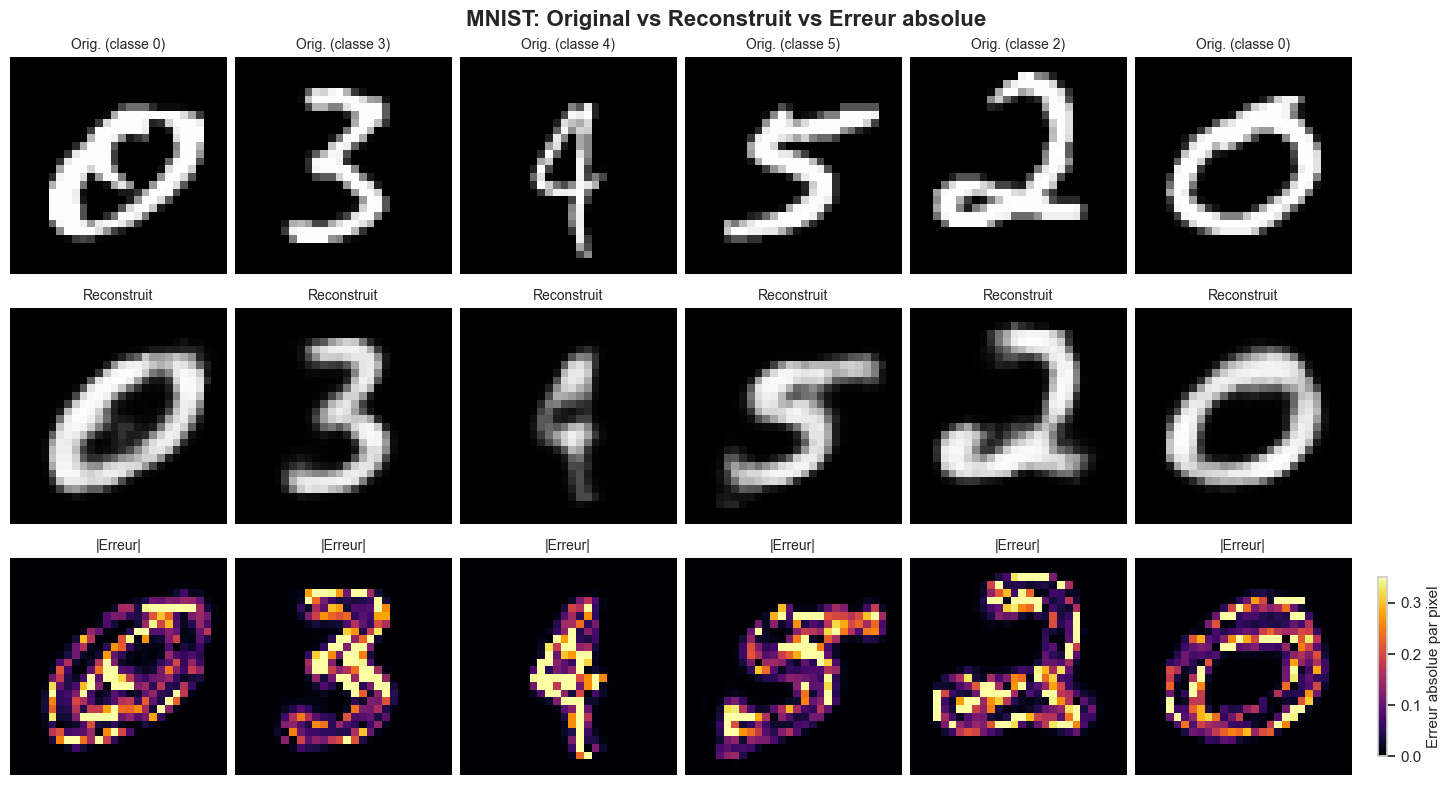

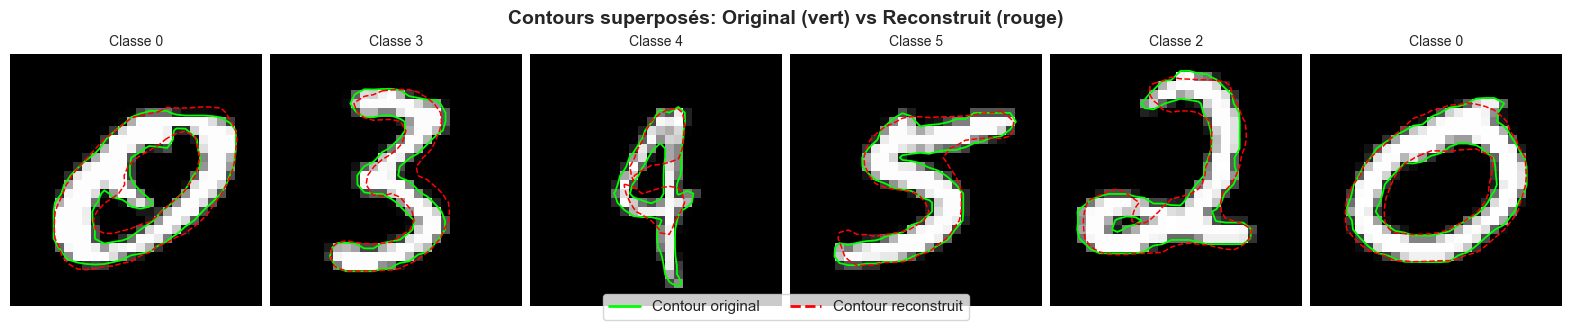

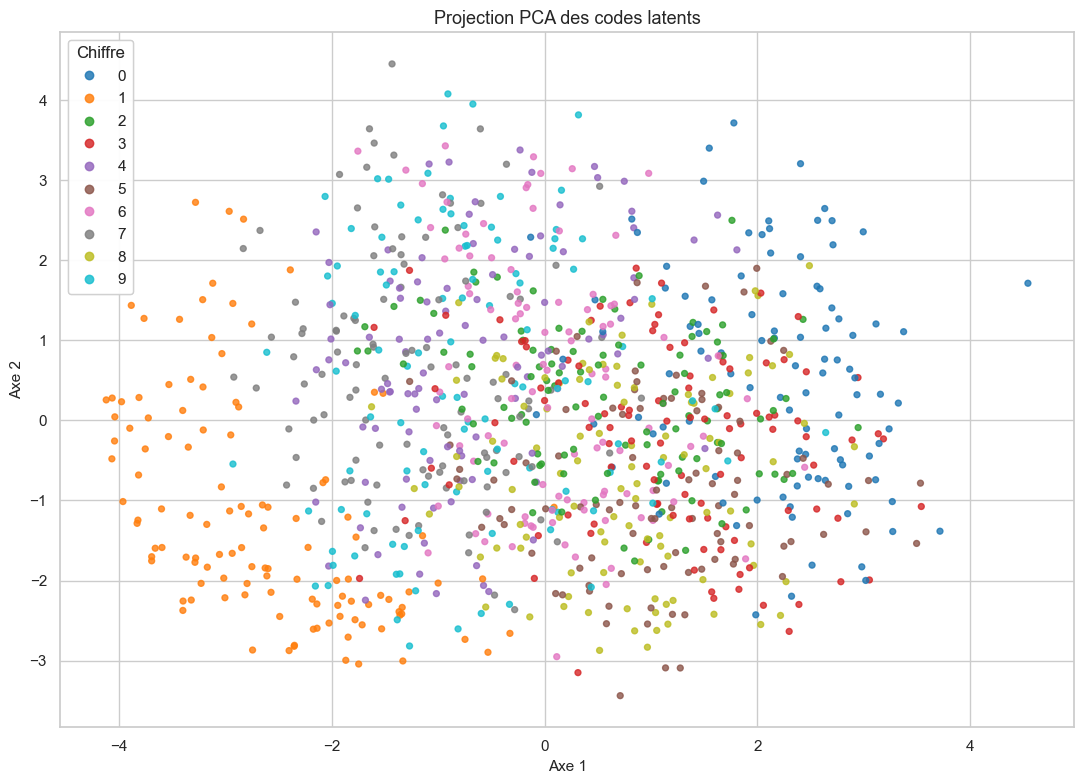

,Metric,Value
0,Validation loss,106.948956
1,Test total loss,99.549221
2,Test BCE recon,91.415686
3,Test KL,31.157401
4,Test MSE,0.018174
5,Test MAE,0.050302
6,Latent dim,32.000000
7,Beta,0.261047


In [5]:
from matplotlib.lines import Line2D

n_show = 6
sample_idx = np.arange(n_show)

fig, axes = plt.subplots(3, n_show, figsize=(2.4 * n_show, 7.8), constrained_layout=True)
fig.suptitle("MNIST: Original vs Reconstruit vs Erreur absolue", fontsize=16, fontweight="bold")

for col, idx in enumerate(sample_idx):
    original_img = X_test[idx].reshape(28, 28)
    recon_img = X_test_recon[idx].reshape(28, 28)
    abs_err = np.abs(original_img - recon_img)

    axes[0, col].imshow(original_img, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"Orig. (classe {y_test[idx]})", fontsize=10)
    axes[0, col].axis("off")

    axes[1, col].imshow(recon_img, cmap="gray", vmin=0, vmax=1)
    axes[1, col].set_title("Reconstruit", fontsize=10)
    axes[1, col].axis("off")

    err_im = axes[2, col].imshow(abs_err, cmap="inferno", vmin=0, vmax=0.35)
    axes[2, col].set_title("|Erreur|", fontsize=10)
    axes[2, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("Reconstruit", fontsize=11)
axes[2, 0].set_ylabel("Erreur", fontsize=11)

cbar = fig.colorbar(err_im, ax=axes[2, :], shrink=0.78, pad=0.02)
cbar.set_label("Erreur absolue par pixel")

plt.show()

fig2, axes2 = plt.subplots(1, n_show, figsize=(2.6 * n_show, 3.2), constrained_layout=True)
fig2.suptitle("Contours superposés: Original (vert) vs Reconstruit (rouge)", fontsize=14, fontweight="bold")

for col, idx in enumerate(sample_idx):
    original_img = X_test[idx].reshape(28, 28)
    recon_img = X_test_recon[idx].reshape(28, 28)

    axes2[col].imshow(original_img, cmap="gray", vmin=0, vmax=1)
    axes2[col].contour(original_img, levels=[0.35], colors=["lime"], linewidths=1.3)
    axes2[col].contour(recon_img, levels=[0.35], colors=["red"], linewidths=1.1, linestyles="--")
    axes2[col].set_title(f"Classe {y_test[idx]}", fontsize=10)
    axes2[col].axis("off")

legend_handles = [
    Line2D([0], [0], color="lime", linewidth=2, label="Contour original"),
    Line2D([0], [0], color="red", linewidth=2, linestyle="--", label="Contour reconstruit"),
]
fig2.legend(handles=legend_handles, loc="lower center", ncol=2, frameon=True)
plt.show()

if latent_test.shape[1] > 2:
    latent_vis = PCA(n_components=2, random_state=42).fit_transform(latent_test)
    latent_title = "Projection PCA des codes latents"
else:
    latent_vis = latent_test
    latent_title = "Espace latent 2D"

fig, ax = plt.subplots(figsize=(11, 8))
scatter = ax.scatter(
    latent_vis[:, 0],
    latent_vis[:, 1],
    c=y_test,
    cmap="tab10",
    s=18,
    alpha=0.8,
)
ax.set_title(latent_title)
ax.set_xlabel("Axe 1")
ax.set_ylabel("Axe 2")
legend = ax.legend(*scatter.legend_elements(), title="Chiffre", loc="best")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

summary = pd.DataFrame([
    {"Metric": "Validation loss", "Value": study.best_value},
    {"Metric": "Test total loss", "Value": test_metrics["total"]},
    {"Metric": "Test BCE recon", "Value": test_metrics["recon"]},
    {"Metric": "Test KL", "Value": test_metrics["kl"]},
    {"Metric": "Test MSE", "Value": test_metrics["mse"]},
    {"Metric": "Test MAE", "Value": test_metrics["mae"]},
    {"Metric": "Latent dim", "Value": best_params["latent_dim"]},
    {"Metric": "Beta", "Value": best_params["beta"]},
])
summary